In [7]:
# Top 3 most interesting topics using Yahoo Finance trending/watchlist/news pages
# No extra installs needed except pandas + requests (usually already installed)

import pandas as pd
import requests
import re
from collections import Counter

def get_top3_interesting_topics():

    urls = [
        "https://finance.yahoo.com/trending-tickers",
        "https://finance.yahoo.com/markets/stocks/trending/",
        "https://finance.yahoo.com/news/"
    ]

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    text = ""

    for url in urls:
        try:
            r = requests.get(url, headers=headers, timeout=10)
            text += r.text + " "
        except:
            pass

    # Find common finance topics / sectors
    keywords = [
        "AI","NVIDIA","TESLA","APPLE","MICROSOFT","BITCOIN","CRYPTO",
        "RATE CUT","FED","RECESSION","CHINA","OIL","GOLD",
        "EARNINGS","TECH","SEMICONDUCTOR","EV"
    ]

    counts = {}

    upper_text = text.upper()

    for word in keywords:
        counts[word] = upper_text.count(word)

    df = pd.DataFrame(
        sorted(counts.items(), key=lambda x: x[1], reverse=True),
        columns=["Topic Name", "Mentions"]
    )

    df = df[df["Mentions"] > 0].head(3).reset_index(drop=True)

    return df

# Run
df = get_top3_interesting_topics()
print(df)

  Topic Name  Mentions
0         AI      8991
1         EV      4423
2       TECH       854


[*********************100%***********************]  5 of 5 completed


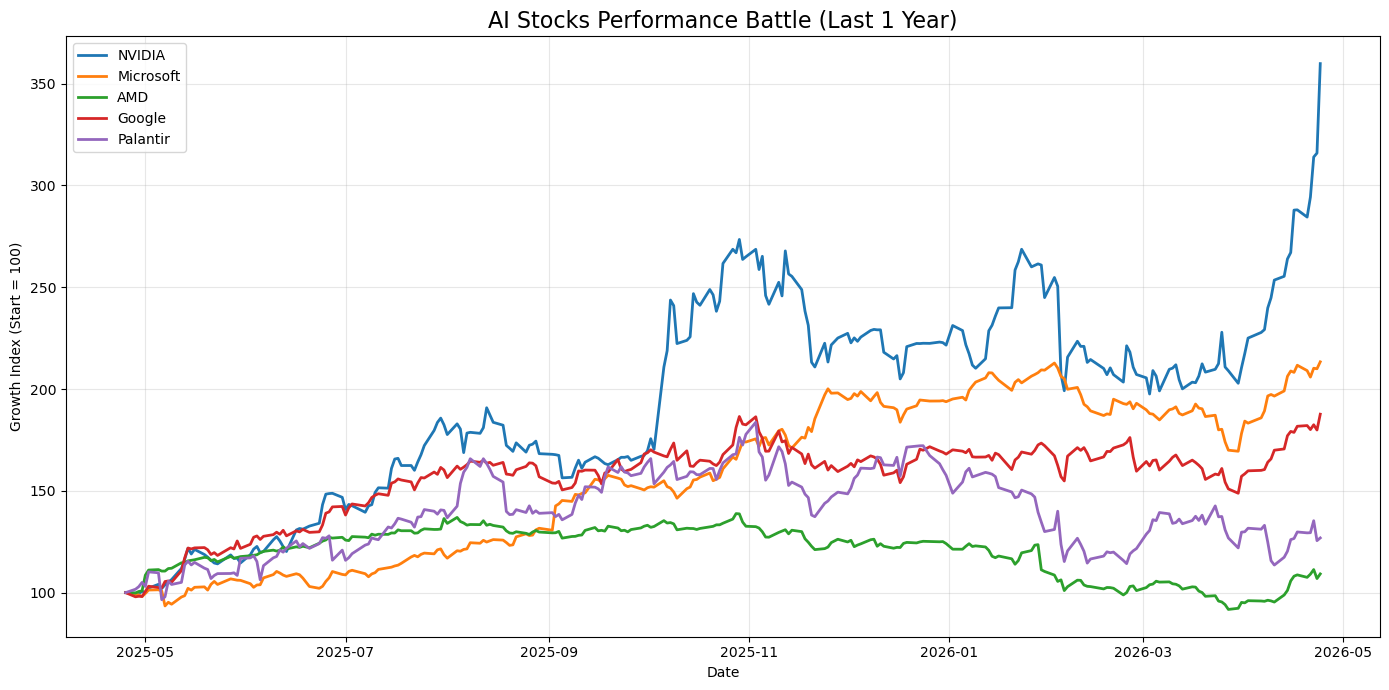

In [9]:
# Interesting AI chart using yfinance
# Compares top AI-related stocks over last 1 year

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# AI basket
tickers = {
    "NVIDIA": "NVDA",
    "Microsoft": "MSFT",
    "AMD": "AMD",
    "Google": "GOOGL",
    "Palantir": "PLTR"
}

# Download data
data = yf.download(list(tickers.values()), period="1y")["Close"]

# Rename columns
data.columns = tickers.keys()

# Normalize to 100 for fair comparison
normalized = data / data.iloc[0] * 100

# Plot
plt.figure(figsize=(14,7))

for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], linewidth=2, label=col)

plt.title("AI Stocks Performance Battle (Last 1 Year)", fontsize=16)
plt.ylabel("Growth Index (Start = 100)")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Selected AI Tickers:
['INTC', 'NVDA', 'AMD', 'SMCI']


[*********************100%***********************]  4 of 4 completed


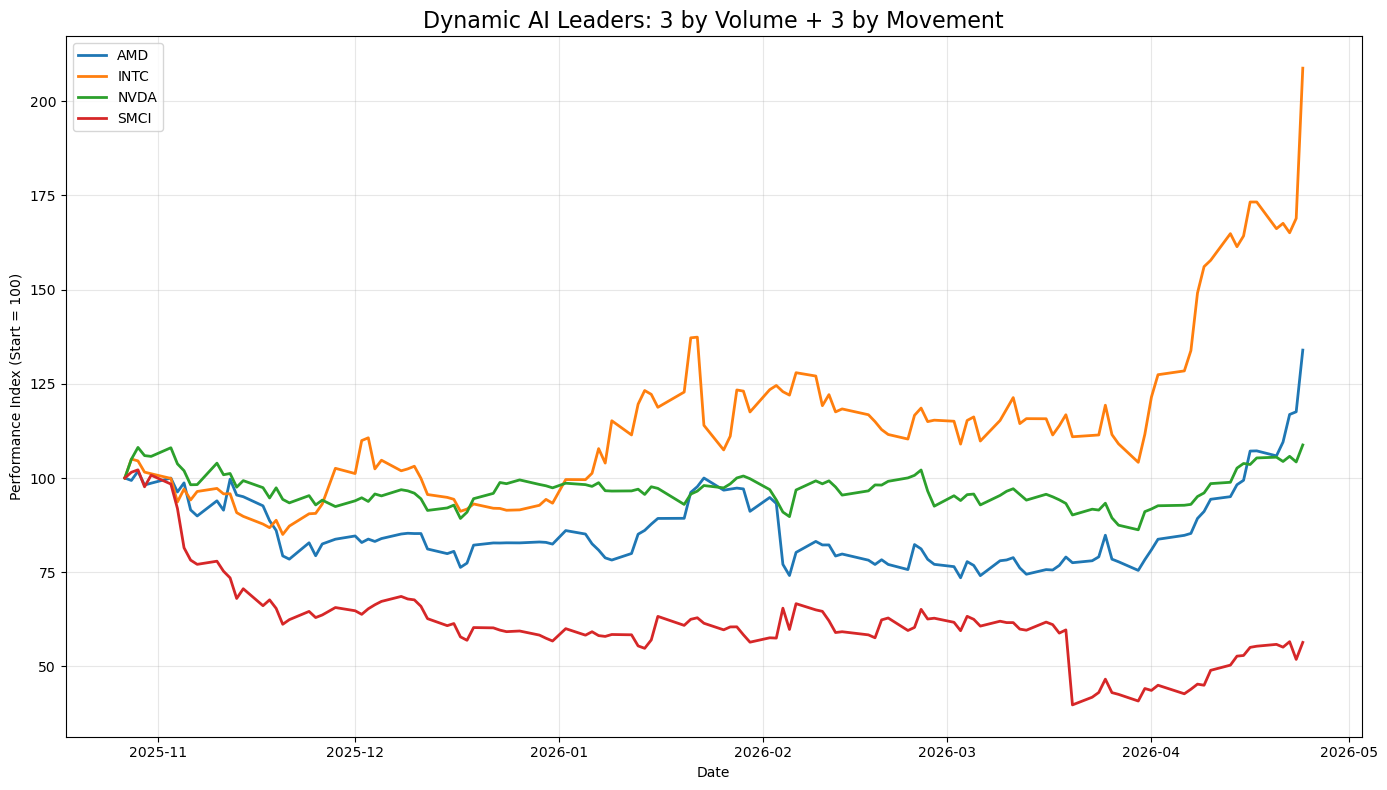

In [10]:
# Dynamic AI chart:
# Finds 6 AI-related tickers automatically:
#   3 highest volume
#   3 biggest daily movers
# Then charts last 6 months normalized performance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Candidate AI universe
ai_universe = [
    "NVDA","AMD","MSFT","GOOGL","META","AMZN","PLTR","TSM",
    "MU","AVGO","SMCI","INTC","CRM","NOW","ADBE","ORCL"
]

rows = []

for ticker in ai_universe:
    try:
        tk = yf.Ticker(ticker)
        info = tk.info

        volume = info.get("volume", 0)
        price = info.get("currentPrice", 0)
        prev = info.get("previousClose", 0)

        if price and prev:
            pct_move = ((price - prev) / prev) * 100
        else:
            pct_move = 0

        rows.append({
            "Ticker": ticker,
            "Volume": volume,
            "PctMove": pct_move
        })

    except:
        pass

df = pd.DataFrame(rows)

# Top 3 by volume
top_volume = df.sort_values("Volume", ascending=False).head(3)

# Top 3 by absolute movement
top_move = df.reindex(df["PctMove"].abs().sort_values(ascending=False).index).head(3)

# Combine unique tickers
selected = pd.concat([top_volume, top_move])["Ticker"].drop_duplicates().head(6).tolist()

print("Selected AI Tickers:")
print(selected)

# Download historical data
prices = yf.download(selected, period="6mo")["Close"]

# Normalize
norm = prices / prices.iloc[0] * 100

# Plot
plt.figure(figsize=(14,8))

for col in norm.columns:
    plt.plot(norm.index, norm[col], linewidth=2, label=col)

plt.title("Dynamic AI Leaders: 3 by Volume + 3 by Movement", fontsize=16)
plt.ylabel("Performance Index (Start = 100)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

[*********************100%***********************]  4 of 4 completed


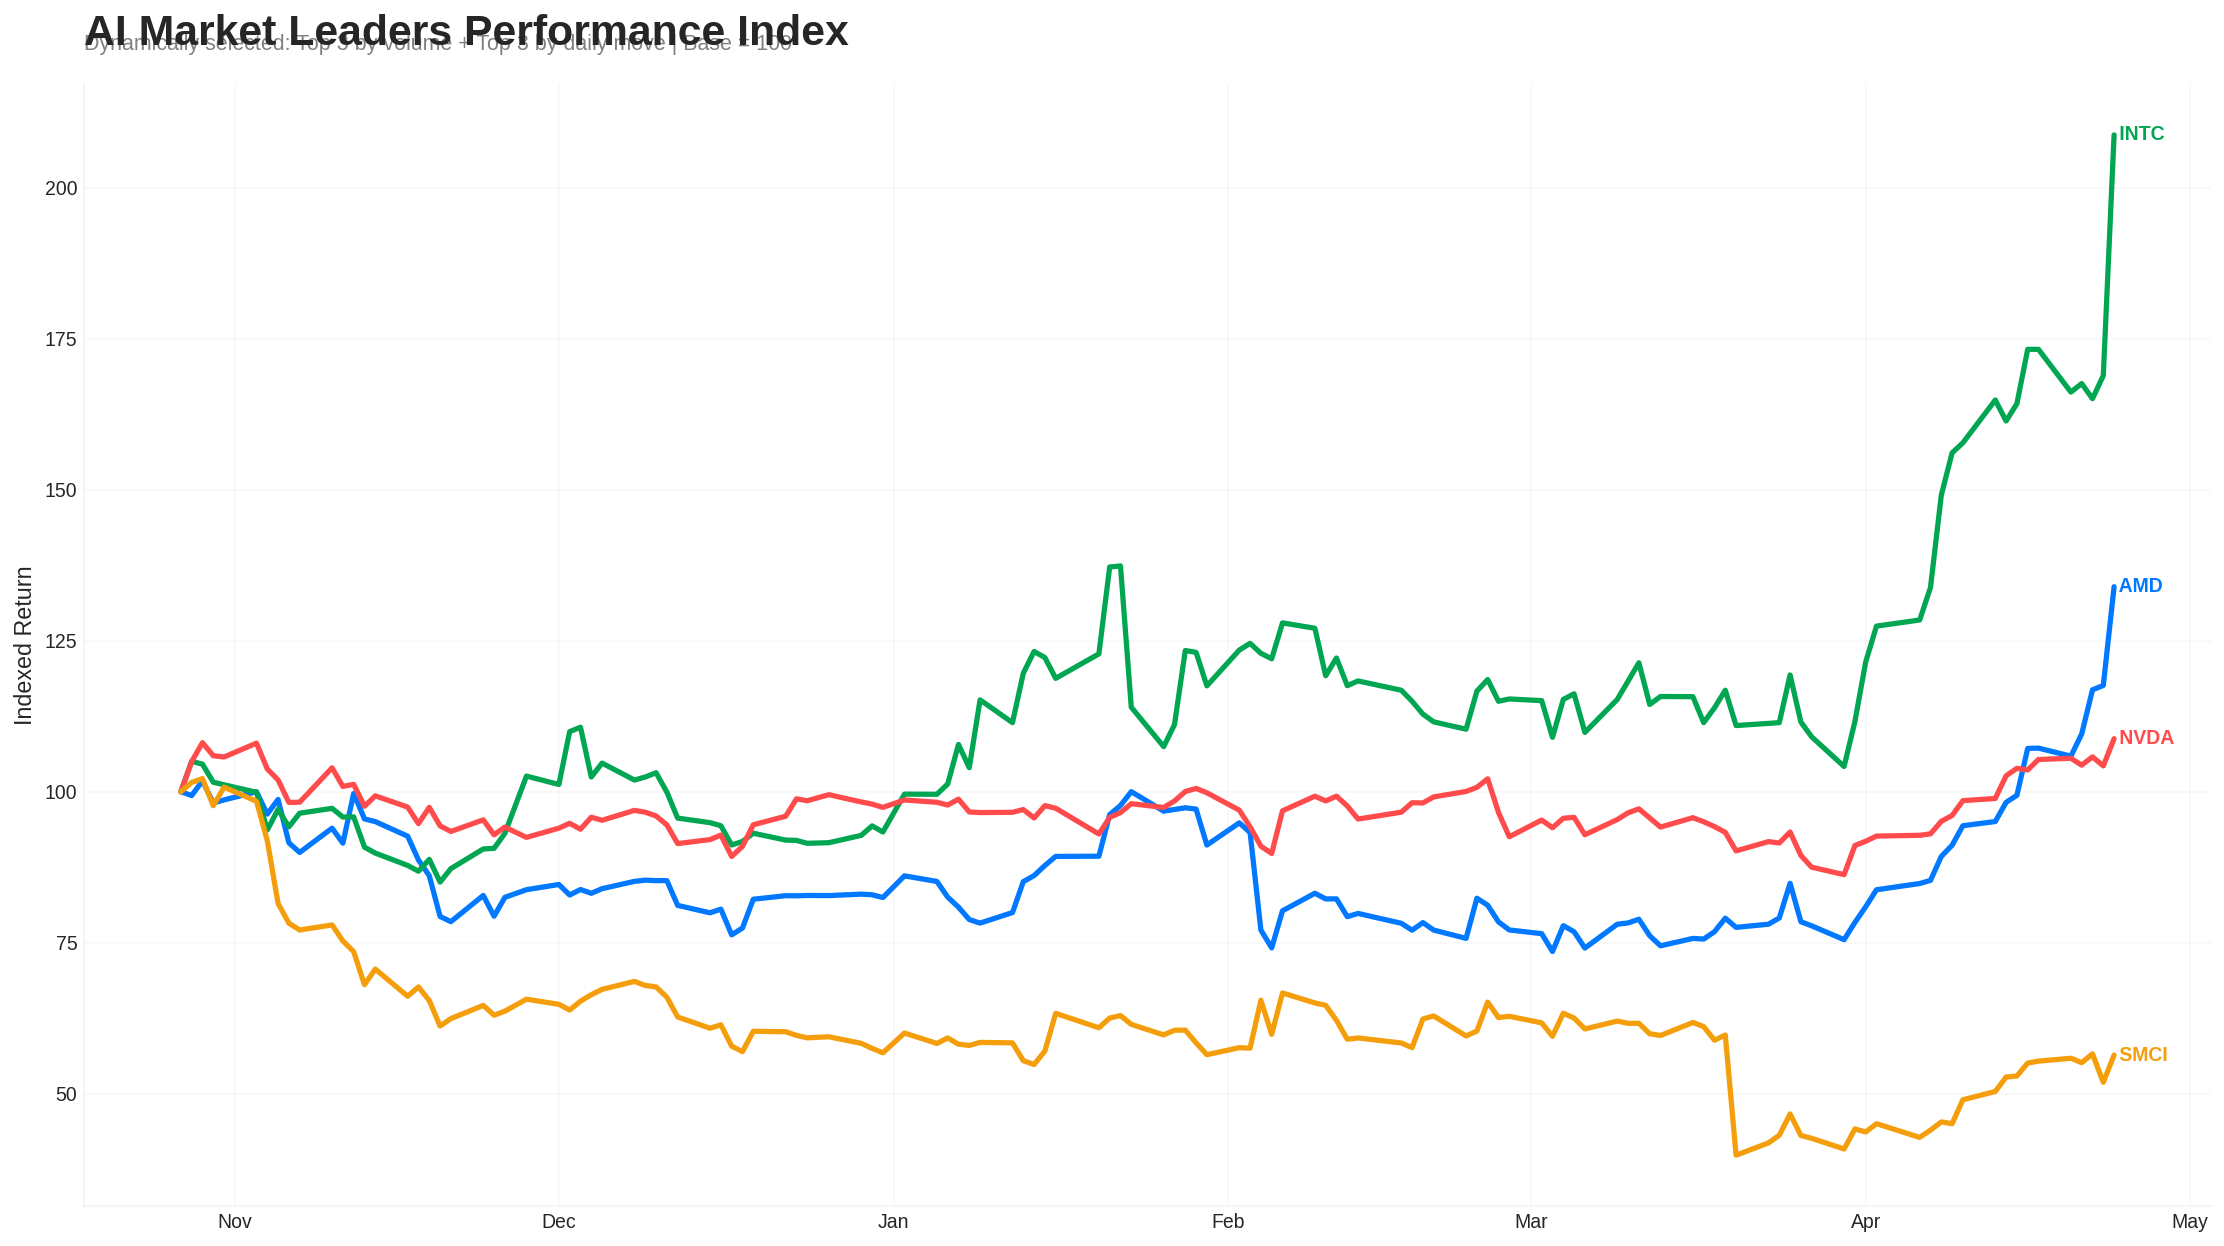

In [11]:
# Professional Yahoo-Finance style chart
# Dynamic AI basket:
# 3 highest volume + 3 biggest movers

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

plt.style.use("seaborn-v0_8-whitegrid")

# -----------------------------
# STEP 1: AI Universe
# -----------------------------
ai_universe = [
    "NVDA","AMD","MSFT","GOOGL","META","AMZN",
    "PLTR","TSM","MU","AVGO","SMCI","INTC"
]

rows = []

for ticker in ai_universe:
    try:
        tk = yf.Ticker(ticker)
        info = tk.info

        volume = info.get("volume", 0)
        price = info.get("currentPrice", 0)
        prev = info.get("previousClose", 0)

        move = ((price - prev) / prev) * 100 if price and prev else 0

        rows.append({
            "Ticker": ticker,
            "Volume": volume,
            "Move": move
        })
    except:
        pass

df = pd.DataFrame(rows)

# -----------------------------
# STEP 2: Pick Leaders
# -----------------------------
top_vol = df.sort_values("Volume", ascending=False).head(3)
top_move = df.reindex(df["Move"].abs().sort_values(ascending=False).index).head(3)

selected = pd.concat([top_vol, top_move])["Ticker"].drop_duplicates().head(6).tolist()

# -----------------------------
# STEP 3: Price History
# -----------------------------
prices = yf.download(selected, period="6mo", auto_adjust=True)["Close"]

# normalize to 100
norm = prices / prices.iloc[0] * 100

# -----------------------------
# STEP 4: Professional Chart
# -----------------------------
fig, ax = plt.subplots(figsize=(16,9), dpi=140)

colors = [
    "#0078ff","#00a651","#ff4b4b",
    "#f59e0b","#8b5cf6","#06b6d4"
]

for i, col in enumerate(norm.columns):
    ax.plot(
        norm.index,
        norm[col],
        linewidth=2.7,
        color=colors[i],
        label=col
    )

    # label last value
    ax.text(
        norm.index[-1],
        norm[col].iloc[-1],
        f" {col}",
        fontsize=10,
        weight="bold",
        color=colors[i],
        va="center"
    )

# -----------------------------
# Styling
# -----------------------------
ax.set_title(
    "AI Market Leaders Performance Index",
    fontsize=22,
    fontweight="bold",
    loc="left",
    pad=20
)

ax.text(
    0,
    1.03,
    "Dynamically selected: Top 3 by volume + Top 3 by daily move | Base = 100",
    transform=ax.transAxes,
    fontsize=11,
    color="gray"
)

ax.set_ylabel("Indexed Return", fontsize=12)
ax.set_xlabel("")

ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.grid(True, alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.2)
ax.spines["bottom"].set_alpha(0.2)

# remove legend (labels on lines)
ax.legend().remove()

plt.tight_layout()
plt.show()

[*********************100%***********************]  4 of 4 completed


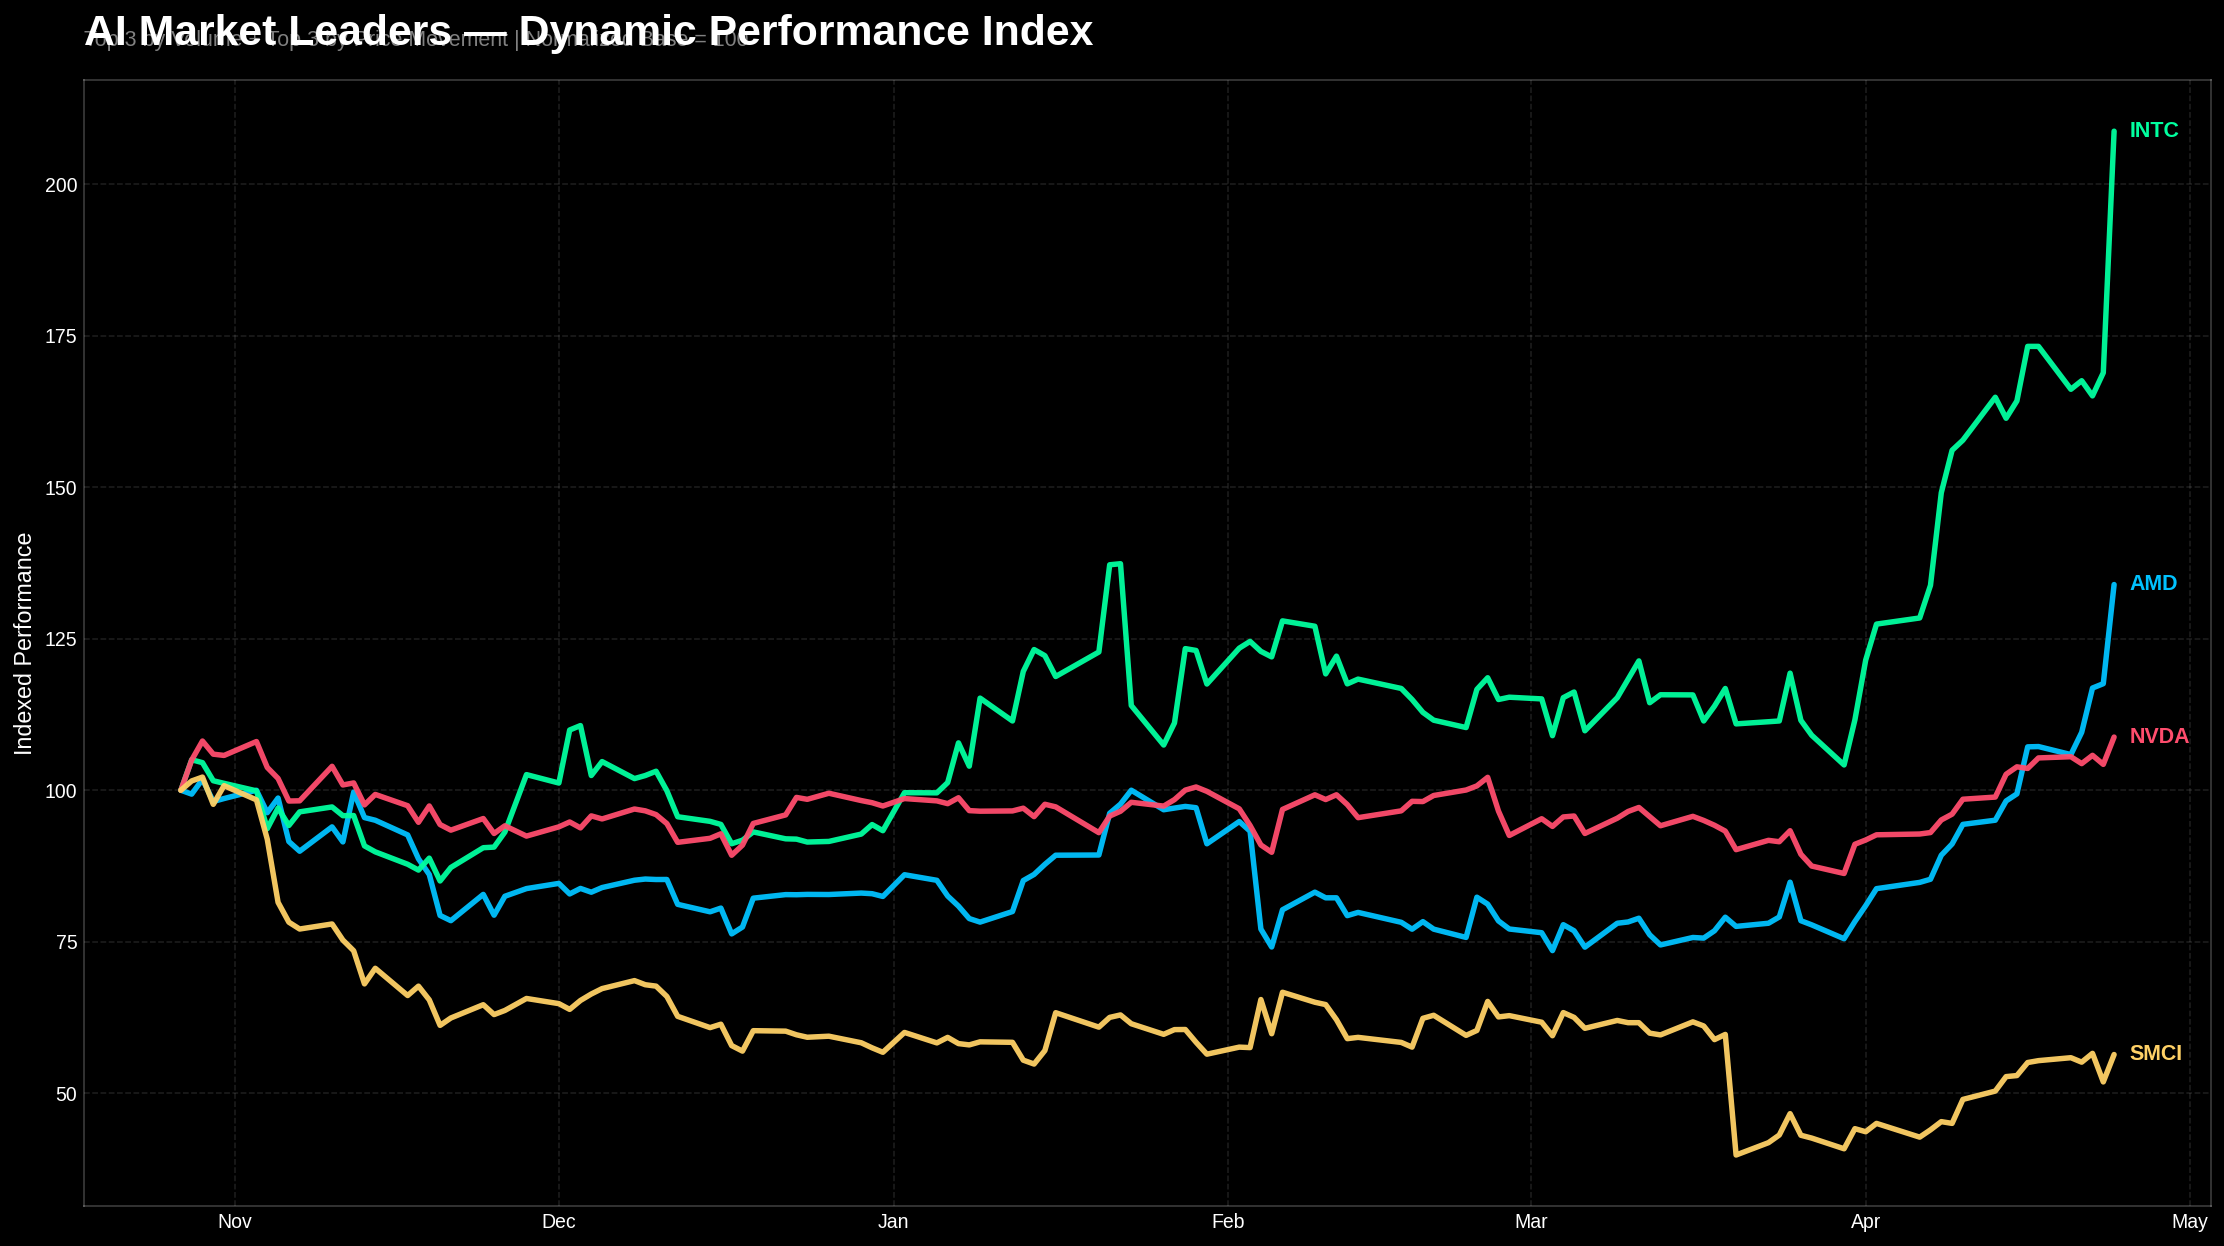

In [12]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

# -----------------------------
# DARK MODE STYLE
# -----------------------------
plt.style.use("dark_background")

# -----------------------------
# AI UNIVERSE
# -----------------------------
ai_universe = [
    "NVDA","AMD","MSFT","GOOGL","META","AMZN",
    "PLTR","TSM","MU","AVGO","SMCI","INTC"
]

rows = []

for ticker in ai_universe:
    try:
        tk = yf.Ticker(ticker)
        info = tk.info

        volume = info.get("volume", 0)
        price = info.get("currentPrice", 0)
        prev = info.get("previousClose", 0)

        move = ((price - prev) / prev) * 100 if price and prev else 0

        rows.append({
            "Ticker": ticker,
            "Volume": volume,
            "Move": move
        })
    except:
        pass

df = pd.DataFrame(rows)

# -----------------------------
# SELECT 6 STOCKS
# -----------------------------
top_vol = df.sort_values("Volume", ascending=False).head(3)
top_move = df.reindex(df["Move"].abs().sort_values(ascending=False).index).head(3)

selected = pd.concat([top_vol, top_move])["Ticker"].drop_duplicates().head(6).tolist()

# -----------------------------
# PRICE DATA
# -----------------------------
prices = yf.download(selected, period="6mo", auto_adjust=True)["Close"]
norm = prices / prices.iloc[0] * 100

# -----------------------------
# DARK PROFESSIONAL CHART
# -----------------------------
fig, ax = plt.subplots(figsize=(16,9), dpi=140)

# modern neon palette (finance-style)
colors = ["#00C2FF","#00FF9F","#FF4D6D","#FFD166","#A78BFA","#38BDF8"]

for i, col in enumerate(norm.columns):
    ax.plot(
        norm.index,
        norm[col],
        linewidth=2.8,
        color=colors[i],
        label=col,
        alpha=0.95
    )

    # endpoint labels (clean finance style)
    ax.annotate(
        f"{col}",
        (norm.index[-1], norm[col].iloc[-1]),
        textcoords="offset points",
        xytext=(8, 0),
        fontsize=11,
        color=colors[i],
        weight="bold",
        va="center"
    )

# -----------------------------
# STYLING (YAHOO FINANCE STYLE)
# -----------------------------
ax.set_title(
    "AI Market Leaders — Dynamic Performance Index",
    fontsize=22,
    fontweight="bold",
    color="white",
    loc="left",
    pad=18
)

ax.text(
    0,
    1.03,
    "Top 3 by Volume + Top 3 by Price Movement | Normalized Base = 100",
    transform=ax.transAxes,
    fontsize=11,
    color="gray"
)

ax.set_ylabel("Indexed Performance", fontsize=12, color="white")

ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# subtle grid (finance look)
ax.grid(True, alpha=0.12, linestyle="--")

# remove borders
for spine in ["top","right","left","bottom"]:
    ax.spines[spine].set_alpha(0.2)

ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

[*********************100%***********************]  4 of 4 completed
/tmp/ipykernel_6024/3240978636.py:99: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


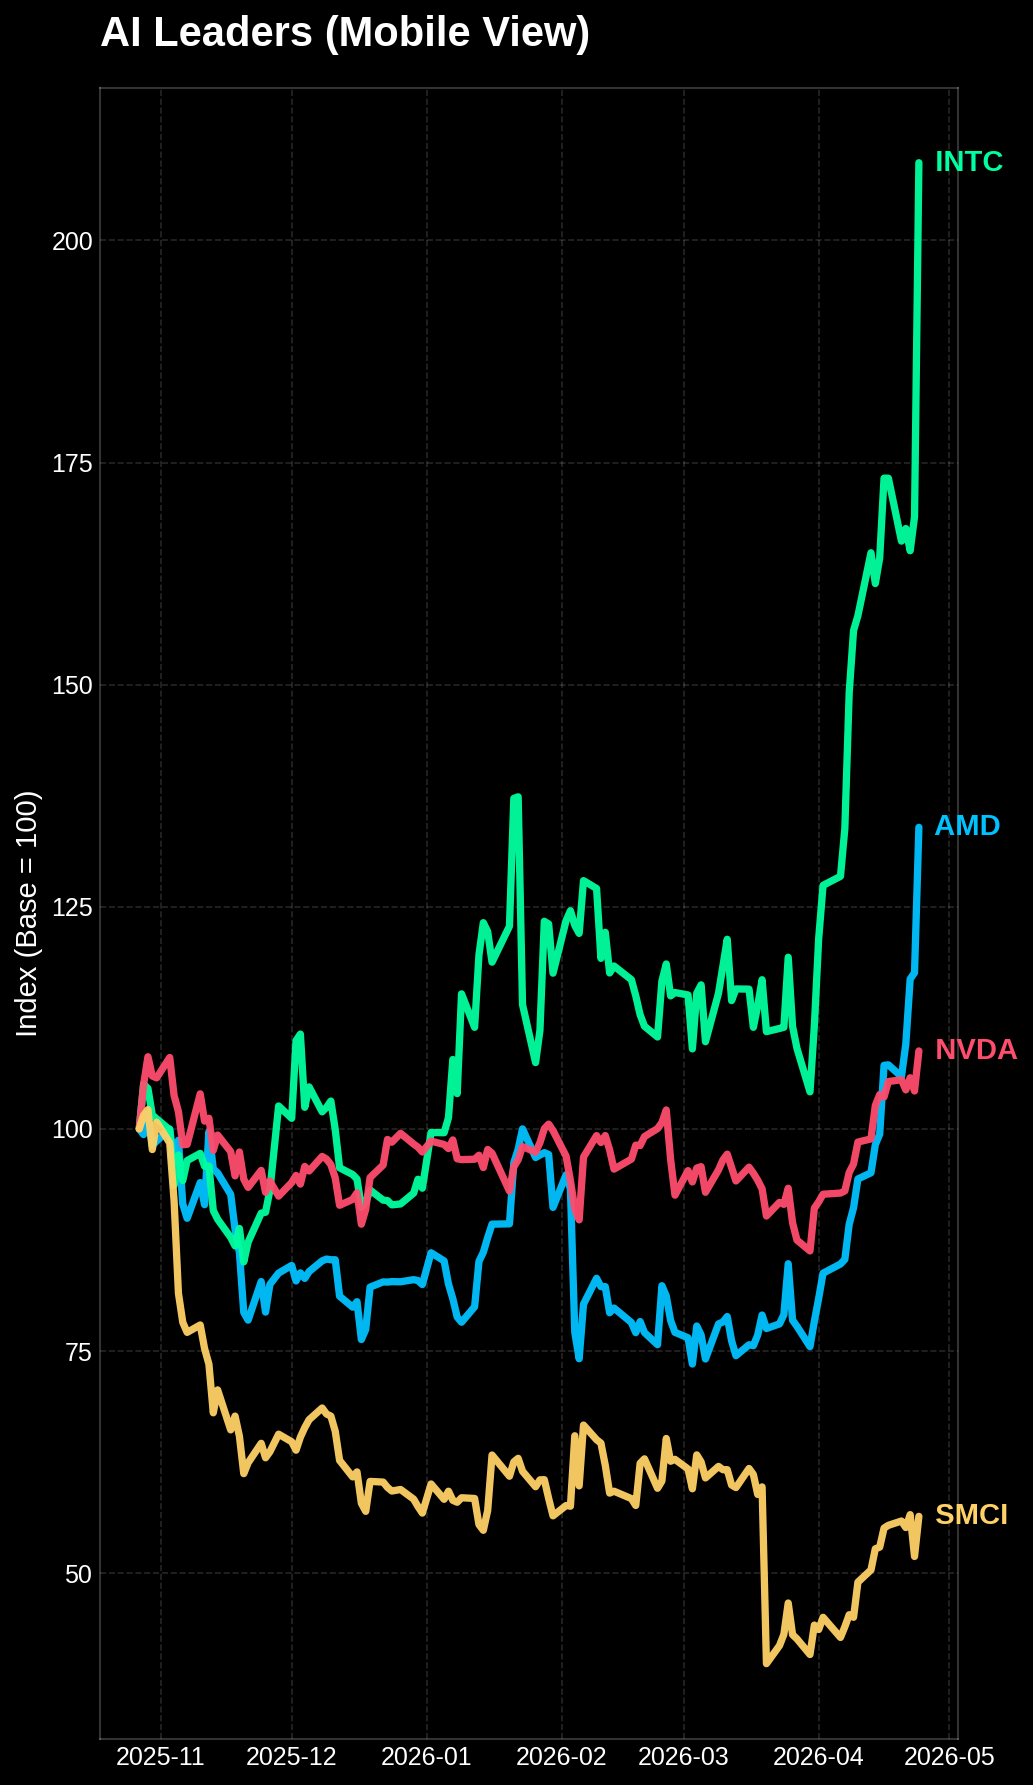

In [13]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("dark_background")

# -----------------------------
# AI UNIVERSE
# -----------------------------
ai_universe = [
    "NVDA","AMD","MSFT","GOOGL","META","AMZN",
    "PLTR","TSM","MU","AVGO","SMCI","INTC"
]

rows = []

for ticker in ai_universe:
    try:
        tk = yf.Ticker(ticker)
        info = tk.info

        volume = info.get("volume", 0)
        price = info.get("currentPrice", 0)
        prev = info.get("previousClose", 0)

        move = ((price - prev) / prev) * 100 if price and prev else 0

        rows.append({
            "Ticker": ticker,
            "Volume": volume,
            "Move": move
        })
    except:
        pass

df = pd.DataFrame(rows)

# -----------------------------
# PICK 6 STOCKS
# -----------------------------
top_vol = df.sort_values("Volume", ascending=False).head(3)
top_move = df.reindex(df["Move"].abs().sort_values(ascending=False).index).head(3)

selected = pd.concat([top_vol, top_move])["Ticker"].drop_duplicates().head(6).tolist()

# -----------------------------
# DATA
# -----------------------------
prices = yf.download(selected, period="6mo", auto_adjust=True)["Close"]
norm = prices / prices.iloc[0] * 100

# -----------------------------
# MOBILE-FIRST CHART
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 12), dpi=150)  # tall phone screen

colors = ["#00C2FF","#00FF9F","#FF4D6D","#FFD166","#A78BFA","#38BDF8"]

for i, col in enumerate(norm.columns):
    ax.plot(
        norm.index,
        norm[col],
        linewidth=3.5,   # thicker for mobile
        color=colors[i],
        alpha=0.95
    )

    # BIG END LABELS (important for phones)
    ax.text(
        norm.index[-1],
        norm[col].iloc[-1],
        f"  {col}",
        fontsize=14,   # 🔥 big readable font
        weight="bold",
        color=colors[i],
        va="center"
    )

# -----------------------------
# MOBILE STYLING
# -----------------------------
ax.set_title(
    "AI Leaders (Mobile View)",
    fontsize=20,
    fontweight="bold",
    color="white",
    loc="left",
    pad=20
)

ax.set_ylabel("Index (Base = 100)", fontsize=14, color="white")

ax.tick_params(axis='both', labelsize=12, colors="white")

ax.grid(True, alpha=0.15, linestyle="--")

# remove clutter
ax.legend().remove()

for spine in ax.spines.values():
    spine.set_alpha(0.2)

plt.tight_layout()
plt.show()

In [2]:
import streamlit as st
import yfinance as yf
import plotly.graph_objects as go
import pandas as pd
import base64
from datetime import datetime

st.set_page_config(page_title="Stock Dashboard", layout="wide")

# ---------------------------
# Sidebar inputs
# ---------------------------
st.sidebar.title("Stock Dashboard")

ticker = st.sidebar.text_input("Enter Ticker", "AAPL")
period = st.sidebar.selectbox("Period", ["1mo", "3mo", "6mo", "1y", "5y"], index=3)

# ---------------------------
# Load data
# ---------------------------
data = yf.download(ticker, period=period)

if data.empty:
    st.error("No data found for ticker.")
    st.stop()

# ---------------------------
# Build chart
# ---------------------------
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=data.index,
        y=data["Close"],
        mode="lines",
        name="Close Price"
    )
)

fig.update_layout(
    title=f"{ticker} Stock Price",
    template="plotly_dark",
    height=500
)

# ---------------------------
# Show chart in Streamlit
# ---------------------------
st.plotly_chart(fig, use_container_width=False, width="stretch")

# ---------------------------
# Save PNG button
# ---------------------------
def save_chart_as_png(fig, filename="chart.png"):
    fig.write_image(filename, engine="kaleido")
    return filename

if st.button("Export Chart as PNG"):
    file_path = save_chart_as_png(fig)

    with open(file_path, "rb") as f:
        data = f.read()
        b64 = base64.b64encode(data).decode()

    href = f'<a href="data:file/png;base64,{b64}" download="{ticker}_chart.png">Download PNG</a>'
    st.markdown(href, unsafe_allow_html=True)

    st.success("PNG ready for download!")

# ---------------------------
# Optional: raw data view
# ---------------------------
with st.expander("Show Raw Data"):
    st.dataframe(data, use_container_width=False)

2026-04-25 17:47:45.604 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 17:47:45.606 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 17:47:45.607 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 17:47:45.608 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 17:47:45.609 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 17:47:45.610 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 17:47:45.611 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 17:47:45.614 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar